In [1]:
from src.xs_and_decays import sigma_analytic,sigma
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("figures.mplstyle")
from scipy.interpolate import interp1d

In [2]:
xs_data = np.loadtxt('data/HNL_xs.txt')
xs_data_interp = interp1d(xs_data[:, 0], xs_data[:, 1], kind='linear', fill_value='extrapolate')

SM_numu_xs = 2.7e-35*1e-4 # m^2

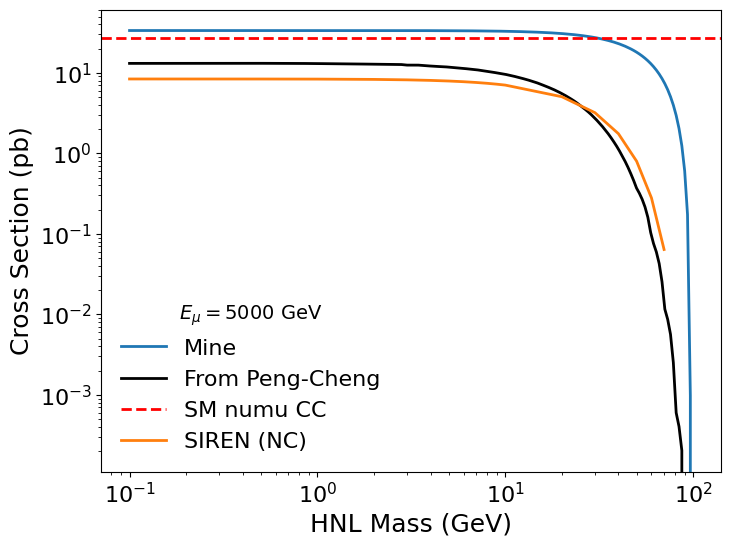

/tmp/ipykernel_4009909/358103126.py:25: RuntimeWarning: divide by zero encountered in divide
  plt.plot(m_N_range, xs_data_interp(m_N_range) / (sigma_analytic(5000, m_N_range, 1)/1e-40/2), color="black")


(0.0, 1.0)

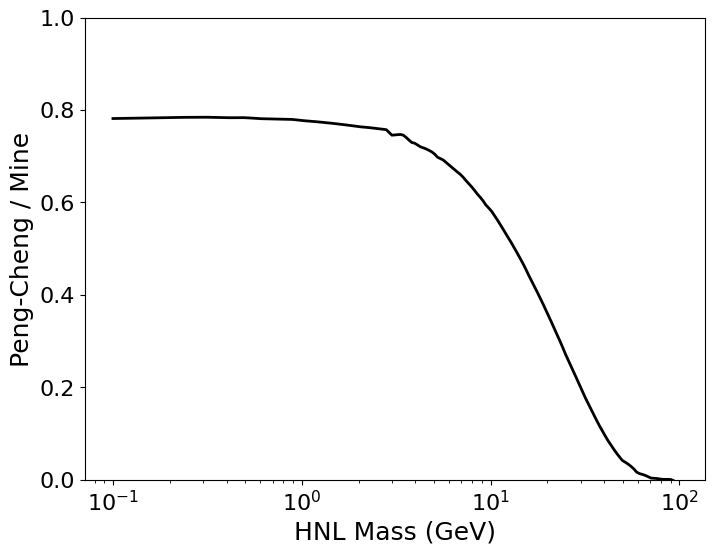

In [3]:
m_N_range = np.logspace(-1, 2, 200)  # HNL mass range from 0.1 to 2 GeV
E_mu_range = [5000]  # Muon energies in GeV
for E_mu in E_mu_range:
    xs = [sigma_analytic(E_mu, m_N, 1)/1e-40 for m_N in m_N_range]
    plt.plot(m_N_range, xs, label='Mine')
plt.plot(m_N_range, xs_data_interp(m_N_range), color="black", label='From Peng-Cheng')
plt.axhline(y=SM_numu_xs/1e-40, color='red', linestyle='--', label='SM numu CC')


import siren
mass_points = [0.1,0.5,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,20,30,40,50.0,60,70]
cross_sections = []
for mass in mass_points:
    cross_sections.append(siren.utilities.load_processes("HNLDISSplines",None,None,True,mass*1e3,1,[0,1,0])[0][siren.dataclasses.NuMu][0].TotalCrossSection(siren.dataclasses.NuMu,5000)/1e-36)

plt.plot(mass_points, cross_sections, label='SIREN (NC)')

plt.xlabel('HNL Mass (GeV)')
plt.ylabel('Cross Section (pb)')
plt.legend(title=r"$E_\mu = %d$ GeV" % E_mu)
plt.loglog()
#plt.ylim(1e-45,1e-38)
plt.show()

plt.plot(m_N_range, xs_data_interp(m_N_range) / (sigma_analytic(5000, m_N_range, 1)/1e-40/2), color="black")
plt.xlabel('HNL Mass (GeV)')
plt.ylabel('Peng-Cheng / Mine')
plt.semilogx()
plt.ylim(0,1)

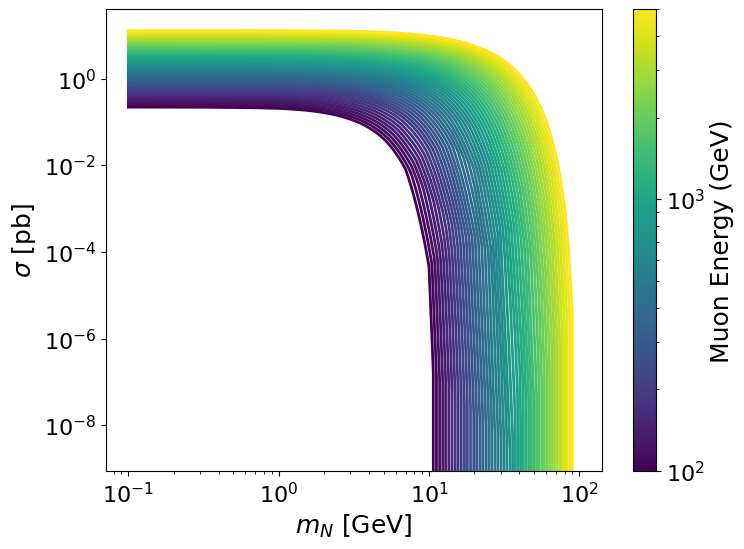

In [4]:
m_N_range = np.logspace(-1, 2, 2000)  # HNL mass range from 0.1 to 2 GeV
E_mu_range = np.logspace(2, np.log10(5000), 50)  # Muon energies in GeV
# color each line by muon energy (log scale)
norm = plt.matplotlib.colors.LogNorm(vmin=E_mu_range.min(), vmax=E_mu_range.max())
cmap = plt.cm.viridis

for E_mu in E_mu_range:
    xs = [sigma(E_mu, m_N, 1)/1e-40 for m_N in m_N_range]
    plt.plot(m_N_range, xs, color=cmap(norm(E_mu)))
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=plt.gca(), label='Muon Energy (GeV)')
plt.xlabel(r'$m_N$ [GeV]')
plt.ylabel(r'$\sigma$ [pb]')
plt.loglog()
plt.savefig("Figures/balloon/energy_dependence_cross_section.png", dpi=300, bbox_inches='tight')
plt.show()